# Logistic Regression Baseline

## Why start with Logistic Regression?

Before using complex models such as Random Forests or XGBoost, we begin with Logistic Regression.

Logistic Regression is simple, fast, and interpretable.

It establishes a baseline performance against which more advanced models can be compared.

---

## Why is it useful?

Unlike tree-based models, Logistic Regression allows us to inspect the importance and direction of each feature.

Positive coefficients increase the probability of an upward move.

Negative coefficients decrease the probability of an upward move.

---

## Objective

Train a baseline model that predicts whether the next day's candle will close higher or lower.

We will evaluate:

- Accuracy
- Precision
- Recall
- Confusion matrix
- Feature coefficients

In [1]:
# imports
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/btc_model_data.csv",
    parse_dates=["Date"]
)
df.head()

,Date,Close,High,Low,Open,Volume,Change,Return,Volume_Change,Momentum_5,MA_10,MA_50,Volatility,RSI,MACD,MACD_Signal,MACD_Hist,Target
0,2020-03-13,67.102943,67.573683,61.063026,63.945388,370732000,3.157555,0.119809,-0.114086,-2.669914,68.219660,73.733391,0.055299,45.241617,-2.642674,-2.022544,-0.620129,0
1,2020-03-16,58.470356,62.542829,57.936853,58.407589,322423600,0.062767,-0.128647,-0.130305,-5.784023,66.853317,73.456120,0.061639,36.847060,-3.202935,-2.258622,-0.944312,1
2,2020-03-17,61.041290,62.187953,57.550594,59.749780,324056000,1.291510,0.043970,0.005063,-7.840782,65.973162,73.244333,0.062905,40.394235,-3.400296,-2.486957,-0.913339,0
3,2020-03-18,59.547001,60.350875,57.241597,57.881318,300233600,1.665683,-0.024480,-0.073513,-6.942753,64.619614,72.991245,0.062721,39.022310,-3.635377,-2.716641,-0.918736,0
4,2020-03-19,59.090748,61.036459,58.566903,59.720811,271857200,-0.630063,-0.007662,-0.094514,-0.832832,63.457498,72.735823,0.062726,38.591330,-3.814524,-2.936218,-0.878306,0


In [3]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Change",
    "Return",
    "Volume_Change",
    "Momentum_5",
    "MA_10",
    "MA_50",
    "Volatility",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

In [4]:
# Split x and y
X = df[features]

y = df["Target"]

In [5]:
# Time split

split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

---

# Feature Scaling

Logistic Regression depends on distances and feature magnitudes.

Our features exist on very different scales:

- RSI ranges from 0–100.
- Bitcoin price ranges in thousands.
- Volatility may be below 0.05.

Without scaling, larger features dominate smaller ones.

We therefore standardize all features.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

--- 
# Training the Model

We fit Logistic Regression on the training set.

The model learns a set of coefficients that relate market indicators to future price movements.


In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
# prediction
predictions = model.predict(
    X_test_scaled
)

In [9]:
# Metrics
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

Accuracy : 0.4091
Precision: 0.4667
Recall   : 0.2014


In [10]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.39      0.69      0.50       103
           1       0.47      0.20      0.28       139

    accuracy                           0.41       242
   macro avg       0.43      0.45      0.39       242
weighted avg       0.43      0.41      0.37       242



# Confusion Matrix

The confusion matrix shows how predictions are distributed.

- True Positive: predicted up, actually up.
- True Negative: predicted down, actually down.
- False Positive: predicted up, actually down.
- False Negative: predicted down, actually up.

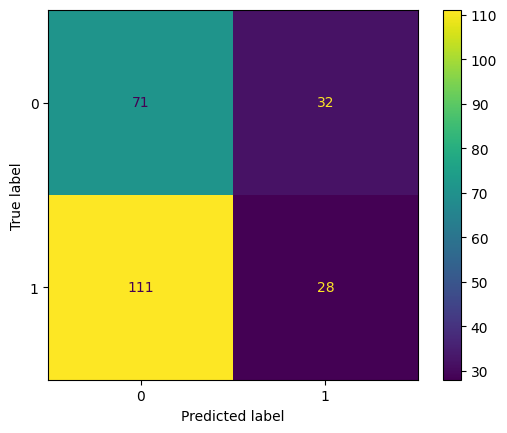

In [11]:
cm = confusion_matrix(
    y_test,
    predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

display.plot()

plt.show()

# Feature Coefficients

Logistic Regression assigns a coefficient to every feature.

Positive values indicate that the feature increases the probability of an upward movement.

Negative values indicate that the feature decreases the probability of an upward movement.

In [12]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
5,Change,0.210035
2,Low,0.192932
10,MA_50,0.181016
9,MA_10,0.143082
12,RSI,0.113526
4,Volume,0.076033
15,MACD_Hist,0.057178
7,Volume_Change,-0.040619
8,Momentum_5,-0.074378
13,MACD,-0.075163


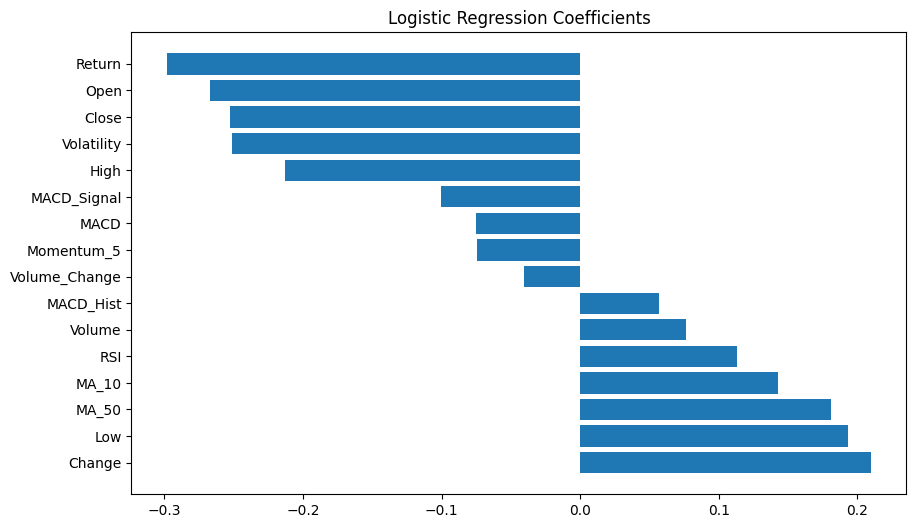

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.title(
    "Logistic Regression Coefficients"
)

plt.show()

### Conclusion

# Logistic Regression Model Performance

Here is the structured summary of the performance metrics and coefficient analysis from your run:

##  Classification Metrics
* **Accuracy:** `0.41` (41%)
* **Precision (Class 1 / Up):** `0.47` (47%)
* **Recall (Class 1 / Up):** `0.20` (20%)

---


##  Model Coefficients Analysis

### Top 5 Positive Coefficients
These features contribute most to predicting an **Up** price movement:

| Feature | Coefficient |
| :--- | :--- |
| **Change** | 0.210035 |
| **Low** | 0.192932 |
| **MA_50** | 0.181016 |
| **MA_10** | 0.143082 |
| **RSI** | 0.113526 |

###  Top 5 Negative Coefficients
These features contribute most to predicting a **Down/Flat** price movement:

| Feature | Coefficient |
| :--- | :--- |
| **Return** | -0.298353 |
| **Open** | -0.267081 |
| **Close** | -0.252338 |
| **Volatility** | -0.251226 |
| **High** | -0.212713 |

# Logistic Regression Analysis

The Logistic Regression model achieved lower performance than the majority-class baseline.

Possible explanations:

- Financial markets exhibit highly non-linear behavior.
- Many features are strongly correlated.
- Logistic Regression assumes linear relationships between indicators and future returns.

Despite poor predictive performance, Logistic Regression serves as an interpretable baseline.

More advanced models such as Random Forest and XGBoost may capture complex interactions more effectively.

In [14]:
# Saving the model
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model saved.")

Model saved.


In [15]:
print(y_test.mean())

0.5743801652892562
